<a href="https://colab.research.google.com/github/Ebrardemir/amazon-sentiment-analysis/blob/main/notebooks/02_Veri_Analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

# Drive'ı bağlayalım
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Görselleştirme ayarları
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

In [ ]:
input_path = '/content/drive/MyDrive/Veri_madenciliği/Dataset/main_kategori_orneklem.csv'

In [ ]:
import pandas as pd

def veriyi_oku_ve_goster(input_path):

    df = pd.read_csv(input_path)
    print("Veri seti başarıyla okundu. İşte ilk 5 satır:\n")
    display(df.head())
    return df
df = veriyi_oku_ve_goster(input_path)

Veri seti başarıyla okundu. İşte ilk 5 satır:



,main_category,parent_asin,user_id,rating,title,text,timestamp,helpful_vote,verified_purchase
0,AMAZON FASHION,B07C1JV4D6,AHFNZX5F56JGJB3YNWA57ZN4APXA,1,Decrease in quality,I previously purchased this band and wire it f...,1580012908597,0,True
1,AMAZON FASHION,B07Y1WXKK7,AGKJS7CWFAIMUF3XSZBD2PLYWPJA,1,Sizing is poor,For slim nine year old the small was way too s...,1628407422155,0,True
2,AMAZON FASHION,B0B5LM3BM4,AHPWHEPY6LTUH3GAB6B2CXAEJ5GQ,1,Band not as pictured,The band I recieved is NOT what was pictured. ...,1607109744225,0,True
3,AMAZON FASHION,B07RM3SH7T,AGCXKLCXMUBUGFDY4EIE6FISFLWQ,1,Didn't come in color that was shown,Didn't come in color that was shown,1646075961857,0,True
4,AMAZON FASHION,B093RXLDX3,AEMPA7MRAT4S6MZHV4W3GTBZVKRQ,1,Don’t buy,They do not work! You can not get the one side...,1675717611577,0,True


In [ ]:
def boyut_goster(df):
    # 0. indeks satır sayısını, 1. indeks ise sütun sayısını verir.
    satir_sayisi = df.shape[0]
    sutun_sayisi = df.shape[1]

    print("--- VERİ SETİ BOYUTU ---")
    print(f"Toplam Satır Sayısı (Gözlem): {satir_sayisi}")
    print(f"Toplam Sütun Sayısı (Değişken): {sutun_sayisi}")
boyut_goster(df)

--- VERİ SETİ BOYUTU ---
Toplam Satır Sayısı (Gözlem): 573500
Toplam Sütun Sayısı (Değişken): 9


In [ ]:
def degiskenleri_goster(df):
    print("*** DEĞİŞKENLER VE VERİ TİPLERİ ***\n")

    df.info()
degiskenleri_goster(df)

*** DEĞİŞKENLER VE VERİ TİPLERİ ***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573500 entries, 0 to 573499
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   main_category      573500 non-null  object
 1   parent_asin        573500 non-null  object
 2   user_id            573500 non-null  object
 3   rating             573500 non-null  int64 
 4   title              573408 non-null  object
 5   text               573393 non-null  object
 6   timestamp          573500 non-null  int64 
 7   helpful_vote       573500 non-null  int64 
 8   verified_purchase  573500 non-null  bool  
dtypes: bool(1), int64(3), object(5)
memory usage: 35.6+ MB


In [ ]:
def eksik_veri_kontrol(df):

    print(" *** EKSİK VERİ KONTROLÜ ***\n")
    eksik_veriler = df.isnull().sum()
    eksik_olanlar = eksik_veriler[eksik_veriler > 0]
    if eksik_olanlar.empty:
        print("Veri setinde  eksik (NaN) veri bulunmamaktadır.")
    else:
        print("Aşağıdaki sütunlarda eksik veriler tespit edildi:\n")


        for sutun, adet in eksik_olanlar.items():
            # Yüzdelik oran hesabı: (Eksik Sayısı / Toplam Satır Sayısı) * 100
            yuzde = (adet / len(df)) * 100
            print(f"-> '{sutun}' sütununda: {adet} adet eksik veri var. (Toplam verinin %{yuzde:.2f}'si)")

# --- KULLANIM ---
eksik_veri_kontrol(df)

 *** EKSİK VERİ KONTROLÜ ***

Aşağıdaki sütunlarda eksik veriler tespit edildi:

-> 'title' sütununda: 92 adet eksik veri var. (Toplam verinin %0.02'si)
-> 'text' sütununda: 107 adet eksik veri var. (Toplam verinin %0.02'si)


*** AYKIRI DEĞER (OUTLIER) ANALİZİ ***

 'helpful_vote' sütunu için Aykırı Değer İstatistikleri:
   - Alt Sınır: -1.50 | Üst Sınır: 2.50
   - Tespit Edilen Aykırı Kayıt Sayısı: 62081 (Toplam verinin %10.82'si)

 'text_length' sütunu için Aykırı Değer İstatistikleri:
   - Alt Sınır: -334.50 | Üst Sınır: 733.50
   - Tespit Edilen Aykırı Kayıt Sayısı: 48789 (Toplam verinin %8.51'si)



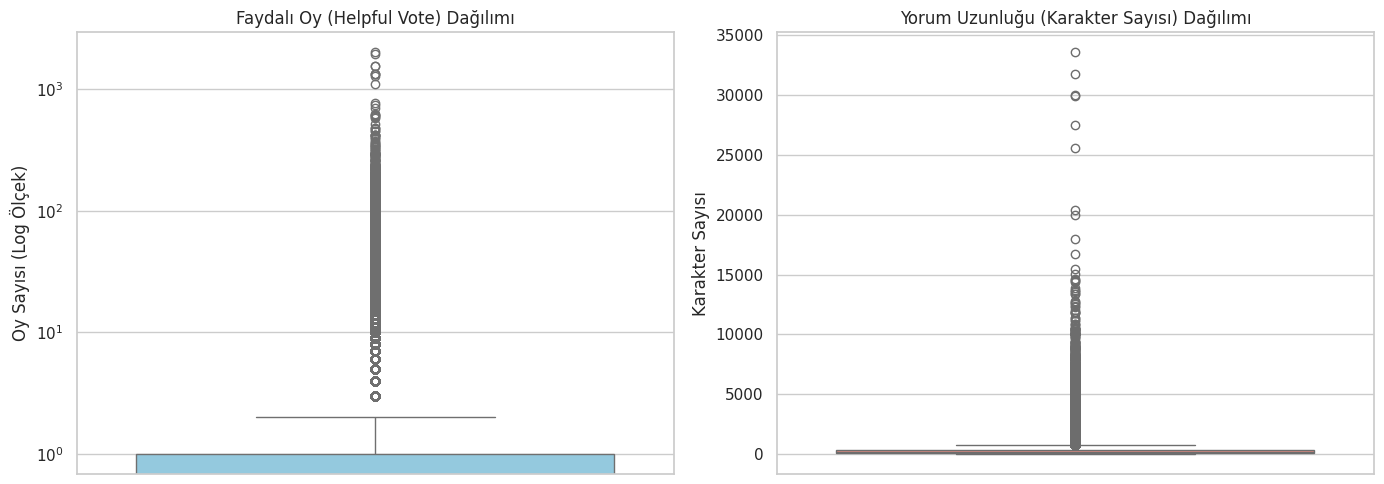

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def aykiri_deger_analizi(df):
    """
    Sayısal değişkenlerdeki ve metin uzunluklarındaki aykırı değerleri
    hem grafiksel olarak (Boxplot) çizer hem de IQR yöntemiyle sayısını hesaplar.
    """
    print("*** AYKIRI DEĞER (OUTLIER) ANALİZİ ***\n")

    # Öncelikle NLP (Metin) analizi için yorum uzunluklarını hesaplayıp yeni bir sütun yapalım
    df['text'] = df['text'].astype(str)
    df['text_length'] = df['text'].apply(len)

    # İnceleyeceğimiz sayısal sütunlar
    incelenecek_sutunlar = ['helpful_vote', 'text_length']

    # 1. BÖLÜM: MATEMATİKSEL HESAPLAMA (IQR YÖNTEMİ)
    for sutun in incelenecek_sutunlar:
        # Çeyreklik dilimleri (Q1: %25, Q3: %75) hesaplıyoruz
        Q1 = df[sutun].quantile(0.25)
        Q3 = df[sutun].quantile(0.75)
        IQR = Q3 - Q1

        # Alt ve Üst sınırları belirliyoruz
        alt_sinir = Q1 - 1.5 * IQR
        ust_sinir = Q3 + 1.5 * IQR

        # Sınırların dışında kalan aykırı değerlerin sayısını buluyoruz
        aykiri_sayisi = df[(df[sutun] < alt_sinir) | (df[sutun] > ust_sinir)].shape[0]
        toplam_veri = df.shape[0]
        yuzde = (aykiri_sayisi / toplam_veri) * 100

        print(f" '{sutun}' sütunu için Aykırı Değer İstatistikleri:")
        print(f"   - Alt Sınır: {alt_sinir:.2f} | Üst Sınır: {ust_sinir:.2f}")
        print(f"   - Tespit Edilen Aykırı Kayıt Sayısı: {aykiri_sayisi} (Toplam verinin %{yuzde:.2f}'si)\n")

    # 2. BÖLÜM: GÖRSELLEŞTİRME (BOXPLOT)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Helpful Vote için Boxplot
    # Amazon oyları genelde çok çarpık olduğu için logaritmik ölçek (log scale) kullanıyoruz
    sns.boxplot(data=df, y='helpful_vote', color='skyblue', ax=axes[0])
    axes[0].set_title('Faydalı Oy (Helpful Vote) Dağılımı')
    axes[0].set_yscale("log")
    axes[0].set_ylabel('Oy Sayısı (Log Ölçek)')

    # Text Length için Boxplot
    sns.boxplot(data=df, y='text_length', color='salmon', ax=axes[1])
    axes[1].set_title('Yorum Uzunluğu (Karakter Sayısı) Dağılımı')
    axes[1].set_ylabel('Karakter Sayısı')

    plt.tight_layout()
    plt.show()

# --- KULLANIM ---
aykiri_deger_analizi(df)

In [ ]:
def istatistiksel_ozet(df):

    print("*** 📈 SAYISAL DEĞİŞKENLERİN İSTATİSTİKLERİ ***\n")
    # Sadece sayısal (rating, helpful_vote vb.) sütunların özetini alıyoruz
    # .T (Transpoze) işlemi tabloyu yan yatırarak daha rahat okunmasını sağlar
    display(df.describe().T)

    print("\n*** METİN VE KATEGORİK DEĞİŞKENLERİN İSTATİSTİKLERİ ***\n")
    # Sadece metin (object) ve mantıksal (bool) tiplerindeki sütunları dahil ediyoruz
    display(df.describe(include=['object', 'bool']).T)

istatistiksel_ozet(df)

*** 📈 SAYISAL DEĞİŞKENLERİN İSTATİSTİKLERİ ***



,count,mean,std,min,25%,50%,75%,max
rating,573500.0,3.050330e+00,1.598107e+00,1.000000e+00,1.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00
timestamp,573500.0,1.531413e+12,1.100961e+11,9.373751e+11,1.456764e+12,1.551326e+12,1.620509e+12,1.694429e+12
helpful_vote,573500.0,1.303057e+00,9.160478e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.010000e+03
text_length,573500.0,2.924596e+02,4.790135e+02,1.000000e+00,6.600000e+01,1.530000e+02,3.330000e+02,3.356800e+04



*** METİN VE KATEGORİK DEĞİŞKENLERİN İSTATİSTİKLERİ ***



,count,unique,top,freq
main_category,573500,15,All Electronics,40000
parent_asin,573500,210620,B00OSTZZ3G,48
user_id,573500,523100,AHMNA5UK3V66O2V3DZSBJA4FYMOA,33
title,573408,370482,Five Stars,18228
text,573500,545403,Good,822
verified_purchase,573500,2,True,514857


*** YILDIZ (RATING) DAĞILIMI ***



,Yorum Sayısı (Adet),Dağılım Oranı (%)
Yıldız (Rating),,
5,150000,26.16
4,149955,26.15
2,125999,21.97
1,147546,25.73


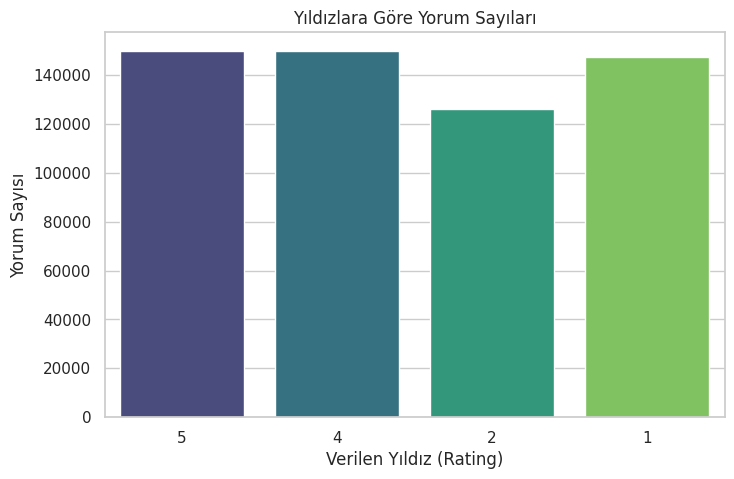

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def rating_dagilimi_goster(df):
    """
    Veri setindeki rating (yıldız) değerlerinin kaçar tane olduğunu
    ve tüm veriye oranını (%) hesaplayıp görselleştirir.
    """
    print("*** YILDIZ (RATING) DAĞILIMI ***\n")

    rating_sayilari = df['rating'].value_counts().sort_index(ascending=False)
    rating_yuzdeleri = df['rating'].value_counts(normalize=True).sort_index(ascending=False) * 100

    ozet_tablo = pd.DataFrame({
        'Yorum Sayısı (Adet)': rating_sayilari,
        'Dağılım Oranı (%)': rating_yuzdeleri.round(2)
    })

    ozet_tablo.index.name = 'Yıldız (Rating)'
    display(ozet_tablo)


    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x='rating', palette='viridis', order=[5, 4, 2, 1])

    plt.title('Yıldızlara Göre Yorum Sayıları')
    plt.xlabel('Verilen Yıldız (Rating)')
    plt.ylabel('Yorum Sayısı')
    plt.show()


rating_dagilimi_goster(df)

*** DEĞİŞKENLER ARASI KORELASYON (İLİŞKİ) ANALİZİ ***



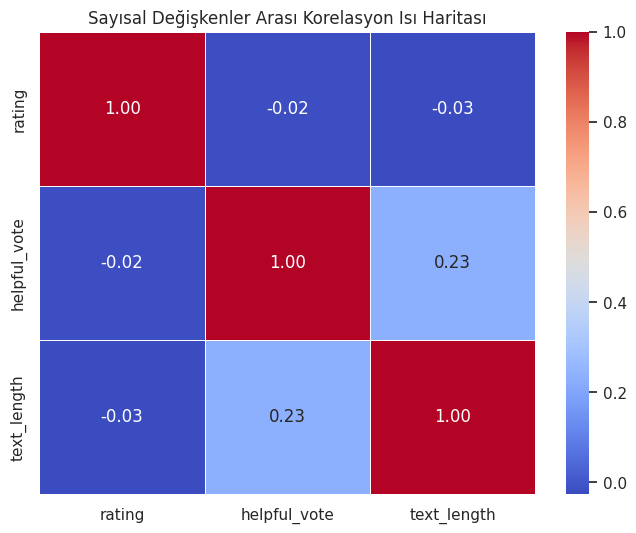

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def korelasyon_matrisi_ciz(df):
    """
    Sayısal değişkenler (yıldız, faydalı oy ve yorum uzunluğu) arasındaki
    ilişkiyi hesaplar ve bir ısı haritası (heatmap) ile görselleştirir.
    """
    print("*** DEĞİŞKENLER ARASI KORELASYON (İLİŞKİ) ANALİZİ ***\n")

    # Metin uzunluğu sütunu (text_length) yoksa her ihtimale karşı tekrar oluşturalım
    if 'text_length' not in df.columns:
        df['text'] = df['text'].astype(str)
        df['text_length'] = df['text'].apply(len)

    # Sadece aralarındaki ilişkiyi incelemek istediğimiz 3 sayısal sütunu seçiyoruz
    sayisal_sutunlar = df[['rating', 'helpful_vote', 'text_length']]

    # Pandas'ın corr() fonksiyonu ile korelasyon matrisini hesaplıyoruz
    korelasyon_matrisi = sayisal_sutunlar.corr()

    # Grafik ayarları ve ısı haritasının çizimi
    plt.figure(figsize=(8, 6))

    # annot=True: Kutuların içine sayıları yazdırır
    # cmap='coolwarm': Negatifleri mavi, pozitifleri kırmızı, sıfırı beyaz yapar
    sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

    plt.title('Sayısal Değişkenler Arası Korelasyon Isı Haritası')
    plt.show()

# --- KULLANIM ---
korelasyon_matrisi_ciz(df)